In [28]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as notebook_tqdm
import pandas as pd

In [29]:
df = pd.read_csv("/kaggle/input/datasets/jahnavisingh1234/lab67dl/Tweets (1).csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [30]:
texts = df["selected_text"].astype(str).tolist()
labels = df["sentiment"].map({"positive": 1, "negative": 0, "neutral": 2}).tolist()

In [31]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

Dataset Class

In [32]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


Load Model (with Attention Output)

In [33]:
# --- your code from the screenshot ---
dataset = SimpleDataset(encodings, labels)
loader = DataLoader(dataset, batch_size=2)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=True
)

# --- ADD THIS HERE, not above ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)   # <-- must be AFTER model is created

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # you already did this

model.train()

total_loss = 0

for batch in loader:
    batch = {k: v.to(device) for k, v in batch.items()}

    optimizer.zero_grad()
    
    outputs = model(**batch)
    loss = outputs.loss
    
    loss.backward()
    optimizer.step()

    total_loss += loss.item()  

avg_loss = total_loss / len(loader)

print("Average Loss:", avg_loss)

Average Loss: 0.3625267472215619


Extract Attention Weights

In [39]:
model.eval()

inputs = tokenizer("I love this product", return_tensors="pt")

# ✅ MOVE INPUTS TO DEVICE
inputs = {k: v.to(device) for k, v in inputs.items()}

# Optional but recommended (faster inference)
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

Visualize Attention Heatmap

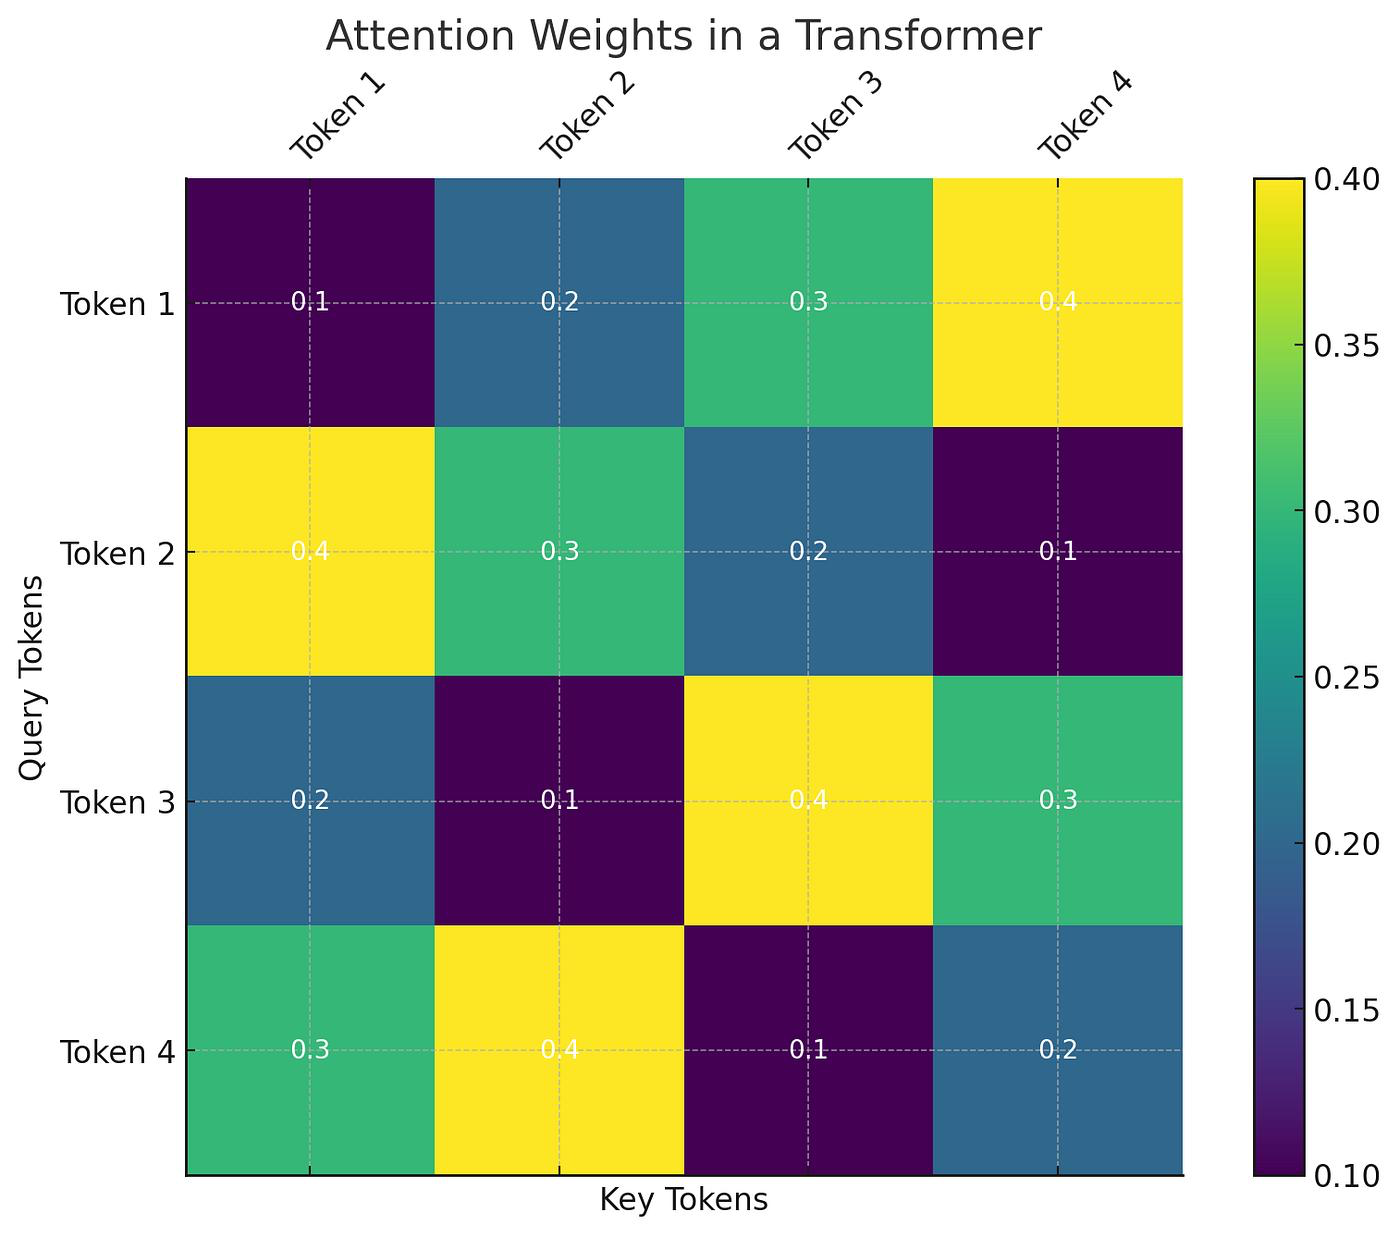
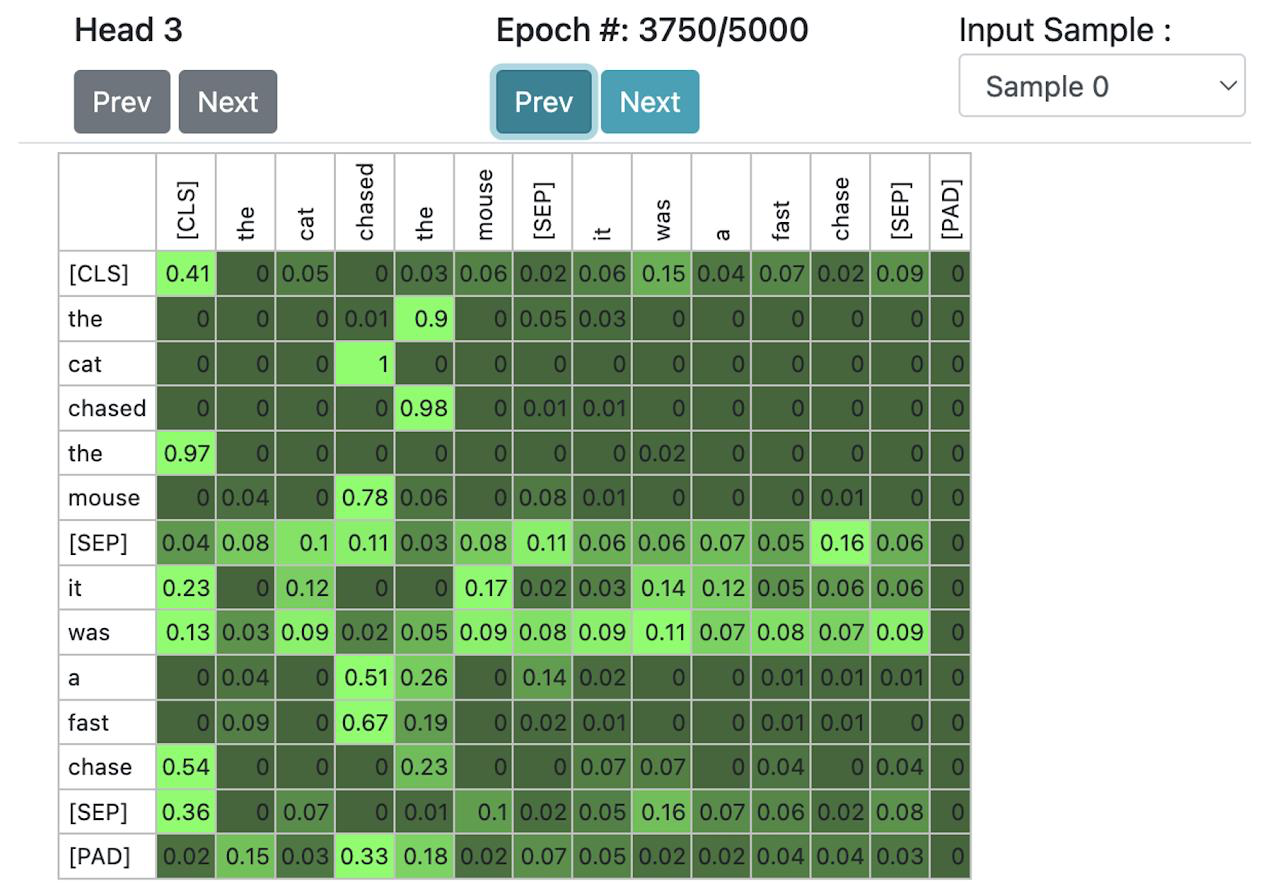

Rows (Y-axis) → Query tokens (who is looking)

Columns (X-axis) → Key tokens (who is being looked at)

Cell value (color intensity) → how much attention is given

in simple words : 

Row = “which word is focusing”

Column = “which word it focuses on”

Example intuition

"This movie is absolutely fantastic"

Typical observations:

“fantastic” → attends to “movie”

→ sentiment word linked to object

“absolutely” → attends to “fantastic”

→ modifier → emphasis


3. Key patterns to look for

(A) Strong diagonal (self-attention)

Words attend to themselves

→ preserves identity


(B) Context linking

“great” → “acting”

“bad” → “movie”

→ sentiment tied to target
(C) Special token [CLS]

Attends broadly to all tokens

→ used for final classification

(D) Long-range dependencies

Example:

"I didn’t like the movie because it was boring"

“didn’t” → “like”

→ negation captured correctly
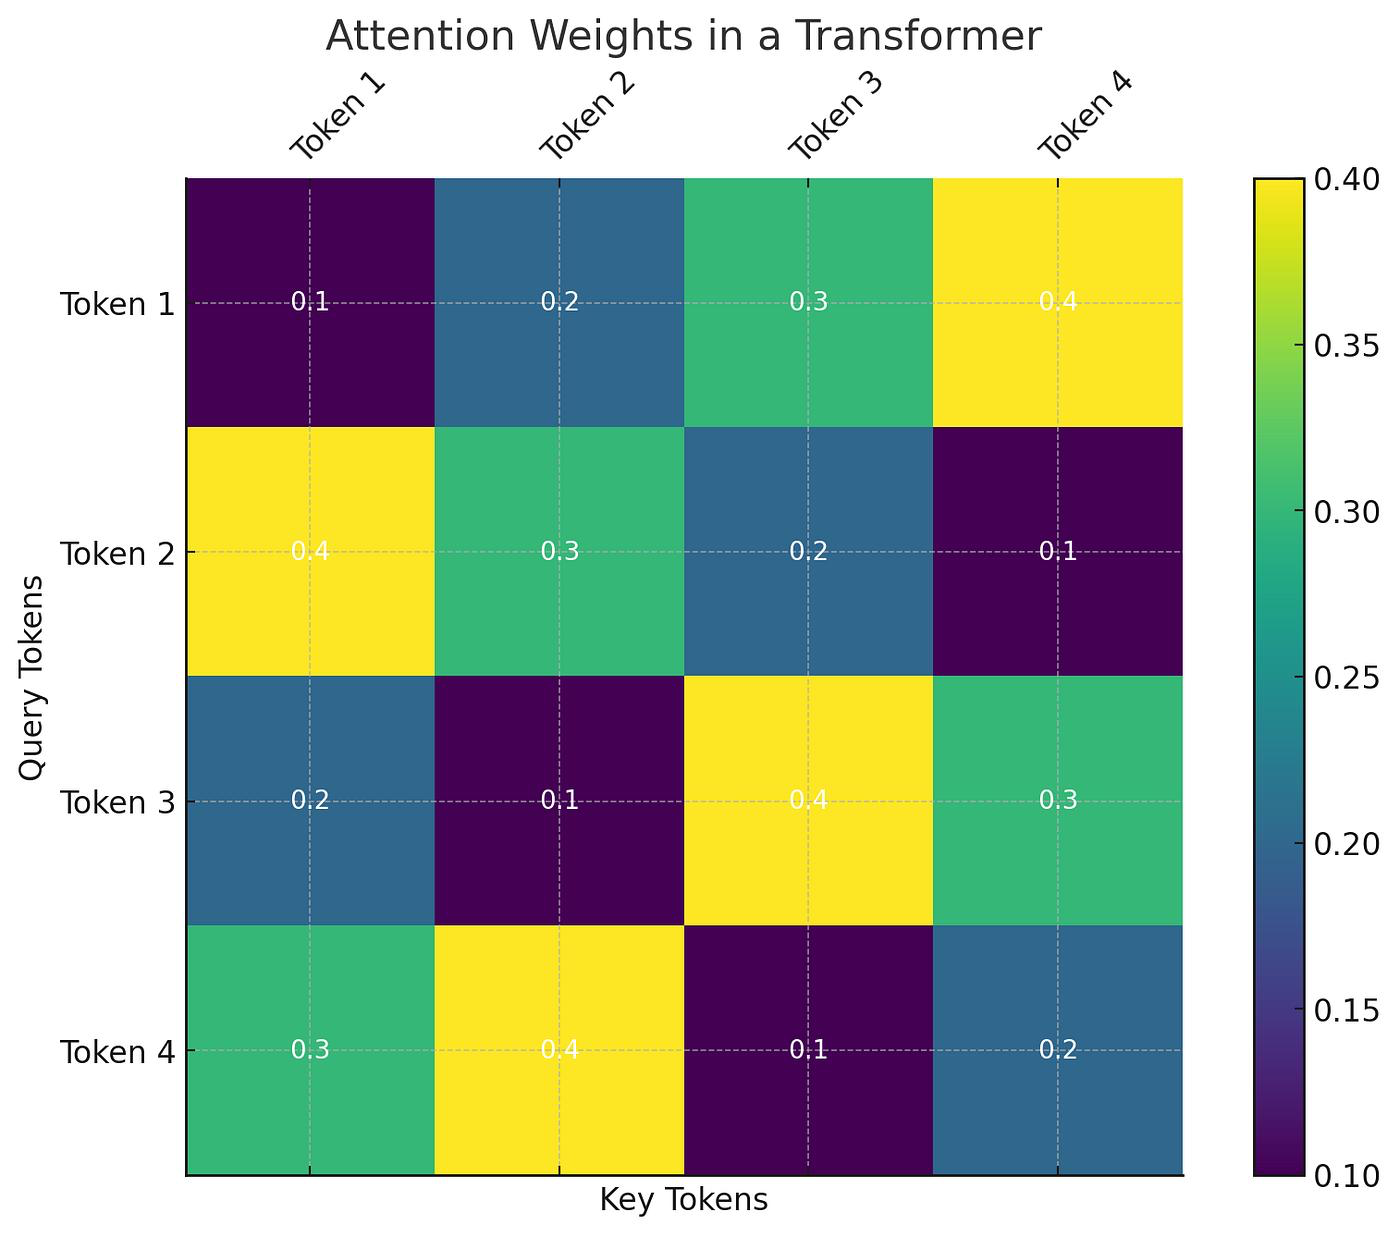
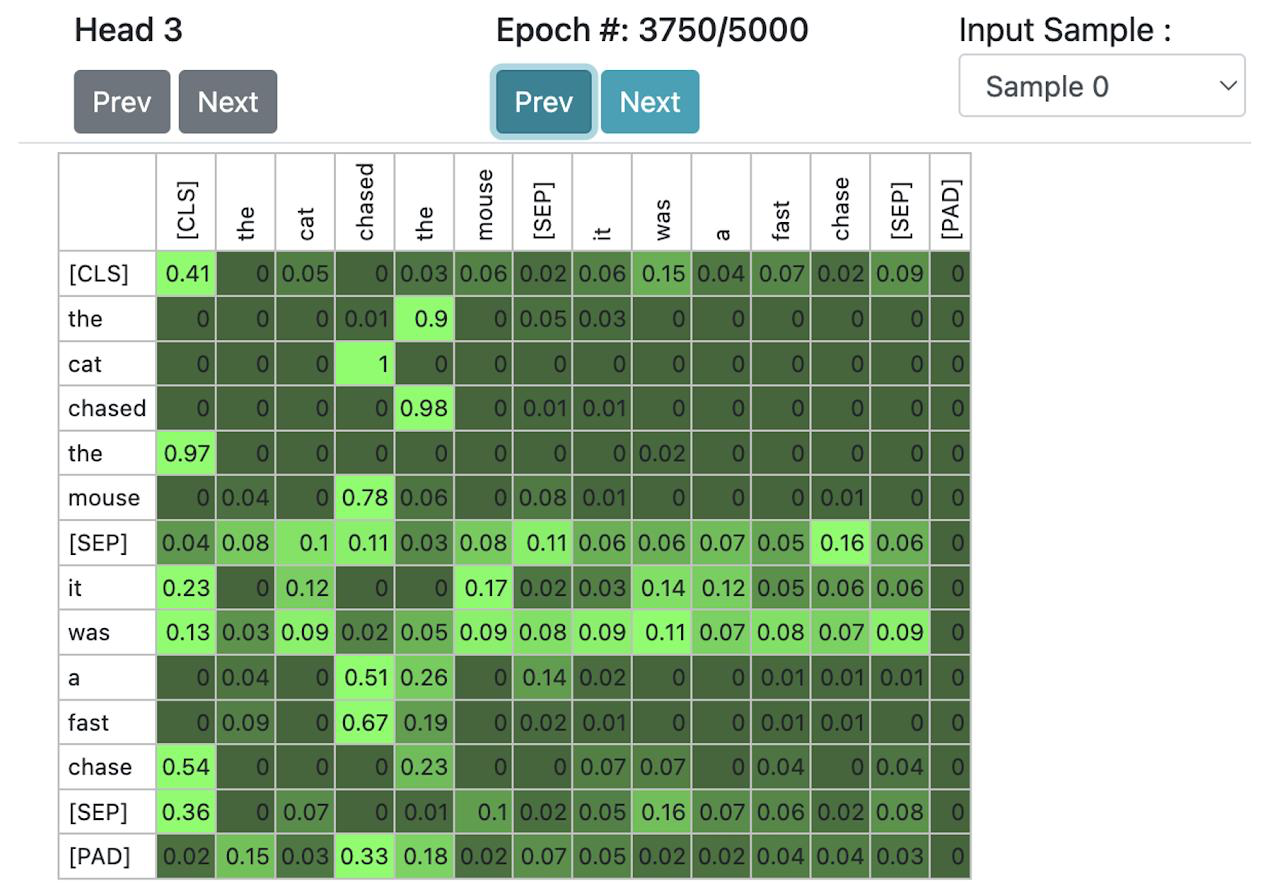

Multi-head attention:

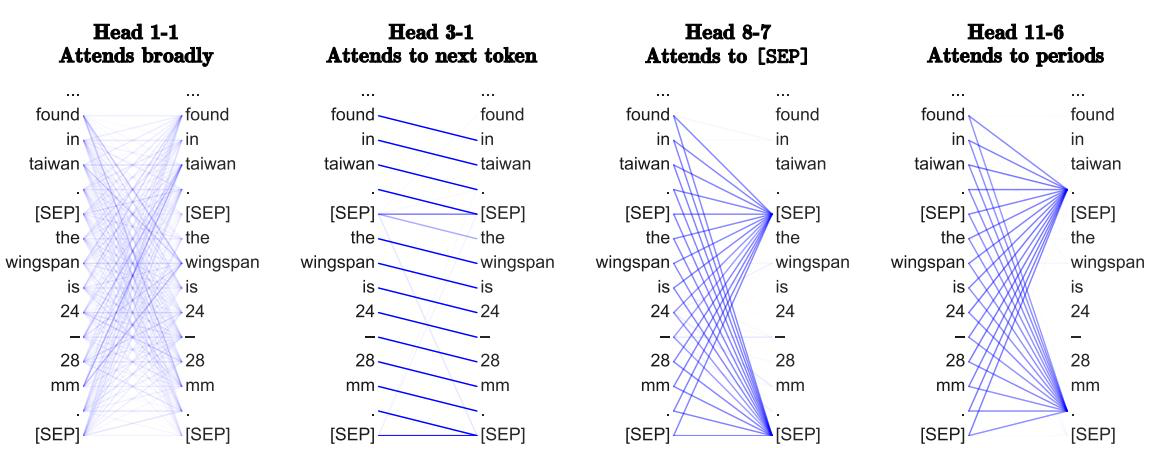

| Head   | What it captures     |
| ------ | -------------------- |
| Head 1 | syntax               |
| Head 2 | sentiment            |
| Head 3 | positional info      |
| Head 4 | long-range relations |


Layer-wise behavior

| Layer         | Role                            |
| ------------- | ------------------------------- |
| Early layers  | local syntax                    |
| Middle layers | phrase structure                |
| Final layers  | task-specific (e.g., sentiment) |

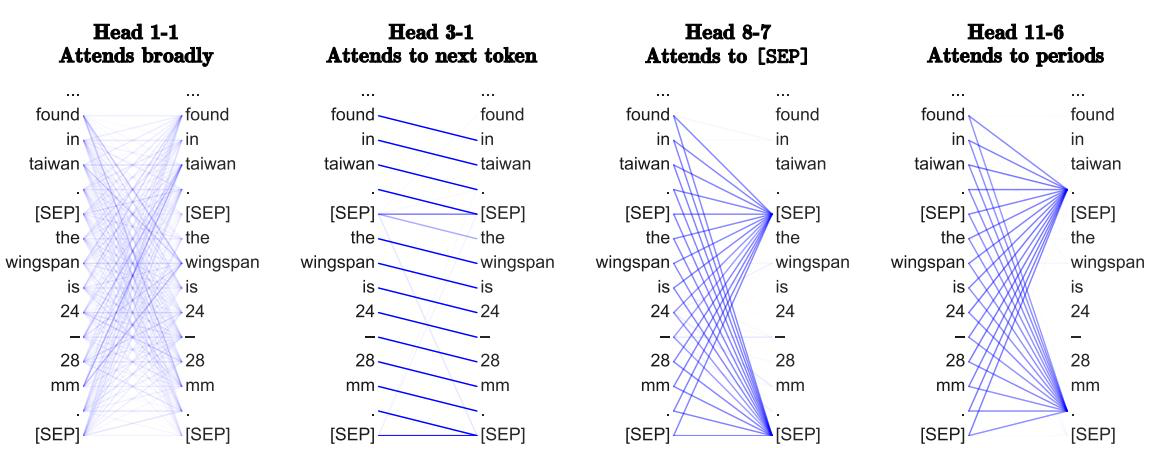

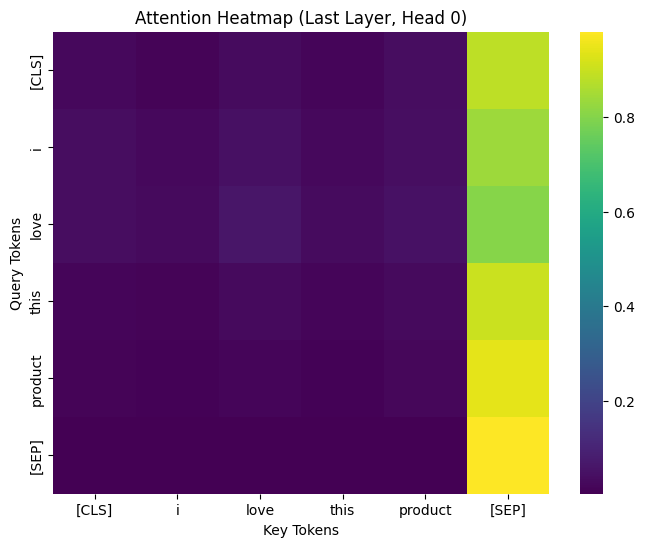

In [41]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# ✅ move to CPU before numpy
attention = attentions[-1][0][0].detach().cpu().numpy()

plt.figure(figsize=(8,6))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Heatmap (Last Layer, Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()